# Flower Classification for AgriTech: Daisy vs Dandelion

**Goal:** a CV model that tells daisies from dandelions, as a prototype for automated plant monitoring (GreenTech Solutions).

**Approach**
- 4 pretrained backbones screened with a frozen backbone (timm, PyTorch)
- Best two fine-tuned (`layer4` unfrozen), with and without augmentation, from the same checkpoint
- Model selected on validation only; test set used once

**Key results**
- **ResNet18 + augmentation:** test macro F1 **0.9378** (11 errors / 182)
- Augmentation helps ResNet18 (+1.1 val points) but not ResNet50
- Robust to motion blur, low light and noise; harsh light, fog and occlusion cost 3–4 points

In [1]:
import os, random, json, copy
import numpy as np
from collections import Counter

import matplotlib.pyplot as plt
from PIL import Image

from sklearn.metrics import classification_report, f1_score, confusion_matrix

import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader
import timm

import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


In [2]:
URL  = "https://proai-datasets.s3.eu-west-3.amazonaws.com/progetto-finale-flowes.tar.gz"
DATA = "/content/data"
ROOT = f"{DATA}/progetto-finale-flowes"

# Download and extract the official dataset only once per session
if not os.path.exists(ROOT):
    os.makedirs(DATA, exist_ok=True)
    !wget -q -O {DATA}/flowers.tar.gz {URL}
    !tar -xzf {DATA}/flowers.tar.gz -C {DATA}

print(f"top level: {sorted(os.listdir(DATA))}")

top level: ['._progetto-finale-flowes', 'flowers.tar.gz', 'progetto-finale-flowes']


In [3]:
# The archive was built on macOS: '._*' AppleDouble files (fake .jpg) and .DS_Store are metadata, not images
removed = 0
for dirpath, _, filenames in os.walk(ROOT):
    for f in filenames:
        if f.startswith('._') or f == '.DS_Store':
            os.remove(os.path.join(dirpath, f))
            removed += 1
print(f"metadata files removed: {removed}")

metadata files removed: 0


The official archive was created on macOS: every image has a hidden `._` twin with a `.jpg` extension,
which doubles the counts and breaks `ImageFolder`. Removing them restores the counts stated in the brief.

## 1. Checking Dataset

In [4]:
classes = sorted(os.listdir(os.path.join(ROOT, 'train')))
print(classes)

['daisy', 'dandelion']


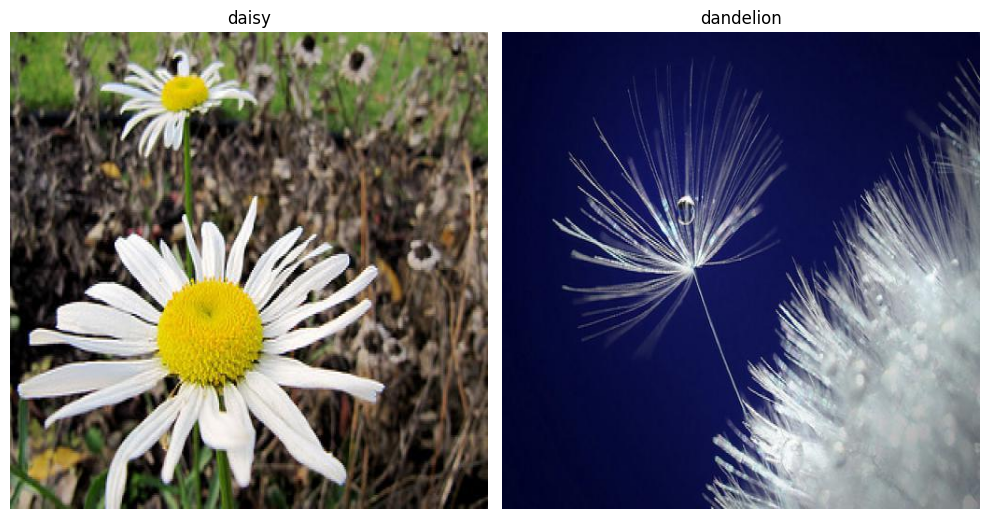

In [5]:
TRAIN = os.path.join(ROOT, 'train')
classes = sorted(os.listdir(TRAIN))

fig, axes = plt.subplots(1, 2, figsize=(10, 8))
for ax, flower in zip(axes.ravel(), classes):
    class_path = os.path.join(TRAIN, flower)
    f = random.choice(os.listdir(class_path))
    ax.imshow(Image.open(os.path.join(class_path, f)))
    ax.set_title(flower)
    ax.axis('off')

axes.ravel()[-1].axis('off')
plt.tight_layout(); plt.show()

In [6]:
%%time
for split in ['train', 'valid', 'test']:
    dataset_path = os.path.join(ROOT, split)
    classes = sorted(d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d)))
    sizes, modes = Counter(), Counter()
    counts = {}   # class -> n. images

    for flower in classes:
        class_path = os.path.join(dataset_path, flower)
        files = os.listdir(class_path)
        counts[flower] = len(files)

        for f in files:
            with Image.open(os.path.join(class_path, f)) as im:
                sizes[im.size] += 1
                modes[im.mode] += 1

    tot = sum(counts.values())

    print(f"\n=== {split.upper()} ({len(classes)} Classes) ===")
    for flower, n in counts.items():
        print(f"  {flower:15s} {n:5d}   {n/tot:6.1%}")
    print("-" * 32)
    print(f"  {'TOTAL':15s} {tot:5d}")
    print(f"\n  Image Type: {dict(modes)} | Image Sizes: {sizes.most_common(3)}")
    print("-" * 64)


=== TRAIN (2 Classes) ===
  daisy             529    41.5%
  dandelion         746    58.5%
--------------------------------
  TOTAL            1275

  Image Type: {'RGB': 1275} | Image Sizes: [((512, 512), 1275)]
----------------------------------------------------------------

=== VALID (2 Classes) ===
  daisy             163    44.8%
  dandelion         201    55.2%
--------------------------------
  TOTAL             364

  Image Type: {'RGB': 364} | Image Sizes: [((512, 512), 364)]
----------------------------------------------------------------

=== TEST (2 Classes) ===
  daisy              77    42.3%
  dandelion         105    57.7%
--------------------------------
  TOTAL             182

  Image Type: {'RGB': 182} | Image Sizes: [((512, 512), 182)]
----------------------------------------------------------------
CPU times: user 134 ms, sys: 28.7 ms, total: 163 ms
Wall time: 170 ms


## Dataset inspection

Checked all 1,821 images.

- **All RGB, all 512×512**
- **Already split** into train/valid/test (1,275 / 364 / 182 → **70% / 20% / 10%**)
- **Imbalanced**: ~42% daisy vs ~58% dandelion → accuracy is misleading  (always predicting *dandelion* already scores 58%)
- Only **1,275 training images** —The problem is overfitting, not model capacity.


## 2. Methods For Training

In [7]:
CKPT_DIR = "/content/models"          # local checkpoints: anyone can rerun the notebook
criterion = nn.CrossEntropyLoss()

In [8]:
class Transforms:
    def __init__(self, transforms):
        self.transforms = transforms

    def __call__(self, img, *args, **kwargs):
        return self.transforms(image=np.array(img))['image']

In [9]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)   # loss is a batch mean: multiply back by batch size
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

In [10]:
def evaluate(model, loader, criterion, device):
  model.eval()
  running_loss, correct, total = 0.0, 0, 0
  y_true, y_pred = [], []

  with torch.no_grad():
    for inputs, labels in loader:
      inputs, labels = inputs.to(device), labels.to(device)

      outputs = model(inputs)
      loss = criterion(outputs, labels)

      running_loss += loss.item() * inputs.size(0)
      _, predicted = torch.max(outputs, 1)

      correct += (predicted == labels).sum().item()
      total += labels.size(0)

      y_true.extend(labels.cpu().numpy())
      y_pred.extend(predicted.cpu().numpy())

  f1 = f1_score(y_true, y_pred, average="macro")

  return running_loss / total, correct / total, f1

In [11]:
class EarlyStopping:
    def __init__(self, save_path, patience=5, min_delta=0):
        self.save_path = save_path
        self.patience = patience
        self.min_delta = min_delta
        self.max_val_f1 = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, validation_f1, model):
        if self.max_val_f1 is None:          # first epoch
            self.max_val_f1 = validation_f1
            self.save_checkpoint(model)

        elif (validation_f1 - self.max_val_f1) > self.min_delta:
            self.max_val_f1 = validation_f1
            self.save_checkpoint(model)
            self.counter = 0

        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.save_path)

In [12]:
def train(model, train_loader, val_loader, criterion, optimizer, device,
          epochs=100, early_stopping=None, scheduler=None):
    train_losses, train_accuracies = [], []
    val_losses, val_accuracies, val_f1s = [], [], []

    for epoch in range(epochs):
        train_loss, train_accuracy = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_accuracy, val_f1 = evaluate(model, val_loader, criterion, device)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)
        val_f1s.append(val_f1)

        print(f'Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.4f}, Val F1: {val_f1:.4f}')

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_f1)
            else:
                scheduler.step()
            print(f"  lr: {optimizer.param_groups[0]['lr']:.1e}")

        if early_stopping is not None:
            early_stopping(val_f1, model)
            if early_stopping.early_stop:
                print("Early stopping")
                break

    if early_stopping is not None:
        model.load_state_dict(torch.load(early_stopping.save_path))
        print(f"Best weights restored (val F1 {early_stopping.max_val_f1:.4f})")

    return train_losses, train_accuracies, val_losses, val_accuracies, val_f1s

In [13]:
def plot_history(train_losses, val_losses, val_f1s, title=''):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(train_losses, label='Train')
    ax1.plot(val_losses, label='Validation')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=.3)

    ax2.plot(val_f1s)
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Macro F1')
    ax2.set_title('Validation Macro F1'); ax2.grid(alpha=.3)

    if title:
        fig.suptitle(title, fontsize=14)
    plt.tight_layout(); plt.show()

In [14]:
def evaluate_report(model, loader, classes, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            outputs = model(inputs.to(device))
            y_pred.extend(outputs.argmax(1).cpu().numpy())
            y_true.extend(labels.numpy())
    print(classification_report(y_true, y_pred, target_names=classes, digits=4))
    return y_true, y_pred

In [15]:
def build_and_train(model_name, train_loader, val_loader, criterion, save_dir, device, lr=1e-3, epochs=50):
    """Pretrained timm model, frozen backbone, only the classifier is trained."""
    m = timm.create_model(model_name, pretrained=True, num_classes=2).to(device)
    for p in m.parameters():                     # freeze backbone
        p.requires_grad = False
    for p in m.get_classifier().parameters():    # train only the new head
        p.requires_grad = True

    os.makedirs(save_dir, exist_ok=True)
    opt = torch.optim.Adam(m.get_classifier().parameters(), lr=lr)
    es  = EarlyStopping(os.path.join(save_dir, 'model.pt'), patience=5, min_delta=0)

    print(f"\n{'='*60}\n{model_name}  —  {sum(p.numel() for p in m.parameters())/1e6:.1f}M params\n{'='*60}")
    hist = train(m, train_loader, val_loader, criterion, opt, device, epochs=epochs, early_stopping=es)

    with open(os.path.join(save_dir, 'log.json'), 'w') as f:    # history next to the checkpoint
        json.dump(dict(zip(['train_losses', 'train_accuracies', 'val_losses', 'val_accuracies', 'val_f1s'], hist)), f)
    return m, hist

In [16]:
def finetune_resnet(base_model, train_loader, val_loader, criterion, save_dir, device, lr=1e-4, epochs=40):
    """Unfreeze layer4 of a ResNet and fine-tune a COPY: the base model is left untouched."""
    m = copy.deepcopy(base_model)                # each branch starts from the same weights
    for p in m.layer4.parameters():
        p.requires_grad = True
    print(f"{sum(p.numel() for p in m.parameters() if p.requires_grad):,} trainable")

    os.makedirs(save_dir, exist_ok=True)
    opt = torch.optim.Adam([p for p in m.parameters() if p.requires_grad], lr=lr)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.1, patience=3)
    es  = EarlyStopping(os.path.join(save_dir, 'model.pt'), patience=8, min_delta=0)

    hist = train(m, train_loader, val_loader, criterion, opt, device, epochs=epochs, early_stopping=es, scheduler=sch)

    with open(os.path.join(save_dir, 'log.json'), 'w') as f:
        json.dump(dict(zip(['train_losses', 'train_accuracies', 'val_losses', 'val_accuracies', 'val_f1s'], hist)), f)
    return m, hist

## 3. Model selection — screening phase

Four candidate backbones, ordered by size.

| Model | Params | timm name |
|:---|---:|:---|
| MobileNetV3-Small | 2.5M | `mobilenetv3_small_100` |
| EfficientNet-B0 | 5.3M | `efficientnet_b0` |
| ResNet18 | 11.7M | `resnet18` |
| ResNet50 | 25.6M | `resnet50` |

All four share ImageNet normalization statistics and a 224×224 input, so a single transform pipeline covers every candidate.

**Screening protocol:** frozen backbone, no augmentation.

Every experiment is run through the same function, so architecture is the only thing that varies.

In [17]:
for name in ['mobilenetv3_small_100', 'efficientnet_b0', 'resnet18', 'resnet50']:
    m = timm.create_model(name, pretrained=True, num_classes=2)
    cfg = m.pretrained_cfg
    n_tot = sum(p.numel() for p in m.parameters())
    print(f"{name:24s} {n_tot/1e6:5.1f}M  input {cfg['input_size']}  "
          f"mean {tuple(round(x,3) for x in cfg['mean'])}  std {tuple(round(x,3) for x in cfg['std'])}")

mobilenetv3_small_100      1.5M  input (3, 224, 224)  mean (0.485, 0.456, 0.406)  std (0.229, 0.224, 0.225)
efficientnet_b0            4.0M  input (3, 224, 224)  mean (0.485, 0.456, 0.406)  std (0.229, 0.224, 0.225)
resnet18                  11.2M  input (3, 224, 224)  mean (0.485, 0.456, 0.406)  std (0.229, 0.224, 0.225)
resnet50                  23.5M  input (3, 224, 224)  mean (0.485, 0.456, 0.406)  std (0.229, 0.224, 0.225)


In [18]:
transform = A.Compose([
            A.Resize(224, 224),
            A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
            ToTensorV2(),
        ])

In [19]:
trainset = torchvision.datasets.ImageFolder(f'{ROOT}/train', transform=Transforms(transform))
valset   = torchvision.datasets.ImageFolder(f'{ROOT}/valid', transform=Transforms(transform))
testset  = torchvision.datasets.ImageFolder(f'{ROOT}/test',  transform=Transforms(transform))

In [20]:
BATCH_SIZE = 32

trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
valloader   = DataLoader(valset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
testloader  = DataLoader(testset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"batches: train {len(trainloader)}, val {len(valloader)}, test {len(testloader)}")

batches: train 40, val 12, test 6


### Model MobileNetV3Small

In [21]:
model_mob, hist_mob = build_and_train('mobilenetv3_small_100', trainloader, valloader, criterion, f'{CKPT_DIR}/MobileNetV3Small', device)


mobilenetv3_small_100  —  1.5M params
Epoch 1/50, Train Loss: 2.7165, Train Acc: 0.6329, Val Loss: 2.4126, Val Acc: 0.6456, Val F1: 0.6391
Epoch 2/50, Train Loss: 1.7612, Train Acc: 0.7090, Val Loss: 1.8027, Val Acc: 0.6896, Val F1: 0.6852
Epoch 3/50, Train Loss: 1.4645, Train Acc: 0.7459, Val Loss: 1.4760, Val Acc: 0.7473, Val F1: 0.7435
Epoch 4/50, Train Loss: 1.1621, Train Acc: 0.7976, Val Loss: 1.2292, Val Acc: 0.7720, Val F1: 0.7703
Epoch 5/50, Train Loss: 0.9144, Train Acc: 0.8165, Val Loss: 1.1331, Val Acc: 0.7940, Val F1: 0.7922
Epoch 6/50, Train Loss: 0.9131, Train Acc: 0.8173, Val Loss: 0.9565, Val Acc: 0.8214, Val F1: 0.8198
Epoch 7/50, Train Loss: 0.7871, Train Acc: 0.8549, Val Loss: 0.9457, Val Acc: 0.8297, Val F1: 0.8278
Epoch 8/50, Train Loss: 0.7220, Train Acc: 0.8525, Val Loss: 0.8355, Val Acc: 0.8352, Val F1: 0.8343
Epoch 9/50, Train Loss: 0.6529, Train Acc: 0.8745, Val Loss: 0.7791, Val Acc: 0.8462, Val F1: 0.8451
Epoch 10/50, Train Loss: 0.5926, Train Acc: 0.8784, 

### Model EfficientNetB0

In [22]:
model_eff, hist_eff = build_and_train('efficientnet_b0', trainloader, valloader, criterion, f'{CKPT_DIR}/EfficientNetB0', device)


efficientnet_b0  —  4.0M params
Epoch 1/50, Train Loss: 2.1428, Train Acc: 0.6149, Val Loss: 1.6673, Val Acc: 0.6731, Val F1: 0.6710
Epoch 2/50, Train Loss: 1.6631, Train Acc: 0.6800, Val Loss: 1.3391, Val Acc: 0.7143, Val F1: 0.7126
Epoch 3/50, Train Loss: 1.2578, Train Acc: 0.7278, Val Loss: 1.1771, Val Acc: 0.7527, Val F1: 0.7508
Epoch 4/50, Train Loss: 1.0427, Train Acc: 0.7482, Val Loss: 1.0071, Val Acc: 0.7830, Val F1: 0.7816
Epoch 5/50, Train Loss: 0.9603, Train Acc: 0.7827, Val Loss: 0.9198, Val Acc: 0.8104, Val F1: 0.8100
Epoch 6/50, Train Loss: 0.8087, Train Acc: 0.8102, Val Loss: 0.8342, Val Acc: 0.8132, Val F1: 0.8122
Epoch 7/50, Train Loss: 0.7852, Train Acc: 0.8227, Val Loss: 0.8183, Val Acc: 0.8242, Val F1: 0.8234
Epoch 8/50, Train Loss: 0.6957, Train Acc: 0.8314, Val Loss: 0.7408, Val Acc: 0.8242, Val F1: 0.8234
Epoch 9/50, Train Loss: 0.6656, Train Acc: 0.8235, Val Loss: 0.7341, Val Acc: 0.8407, Val F1: 0.8405
Epoch 10/50, Train Loss: 0.6252, Train Acc: 0.8369, Val Lo

### Model ResNet18

In [23]:
model_r18, hist_r18 = build_and_train('resnet18', trainloader, valloader, criterion, f'{CKPT_DIR}/ResNet18', device)


resnet18  —  11.2M params
Epoch 1/50, Train Loss: 0.5783, Train Acc: 0.7200, Val Loss: 0.4742, Val Acc: 0.8571, Val F1: 0.8544
Epoch 2/50, Train Loss: 0.4179, Train Acc: 0.8729, Val Loss: 0.3759, Val Acc: 0.8929, Val F1: 0.8912
Epoch 3/50, Train Loss: 0.3522, Train Acc: 0.8855, Val Loss: 0.3301, Val Acc: 0.9011, Val F1: 0.9002
Epoch 4/50, Train Loss: 0.3139, Train Acc: 0.9004, Val Loss: 0.3013, Val Acc: 0.9148, Val F1: 0.9138
Epoch 5/50, Train Loss: 0.2862, Train Acc: 0.8973, Val Loss: 0.2787, Val Acc: 0.9066, Val F1: 0.9060
Epoch 6/50, Train Loss: 0.2660, Train Acc: 0.9051, Val Loss: 0.2666, Val Acc: 0.9121, Val F1: 0.9118
Epoch 7/50, Train Loss: 0.2479, Train Acc: 0.9216, Val Loss: 0.2484, Val Acc: 0.9148, Val F1: 0.9141
Epoch 8/50, Train Loss: 0.2401, Train Acc: 0.9184, Val Loss: 0.2476, Val Acc: 0.9066, Val F1: 0.9060
Epoch 9/50, Train Loss: 0.2247, Train Acc: 0.9286, Val Loss: 0.2288, Val Acc: 0.9203, Val F1: 0.9196
Epoch 10/50, Train Loss: 0.2240, Train Acc: 0.9271, Val Loss: 0.

### Model ResNet50

In [24]:
model_r50, hist_r50 = build_and_train('resnet50', trainloader, valloader, criterion, f'{CKPT_DIR}/ResNet50', device)


resnet50  —  23.5M params
Epoch 1/50, Train Loss: 0.5602, Train Acc: 0.7443, Val Loss: 0.4529, Val Acc: 0.8901, Val F1: 0.8851
Epoch 2/50, Train Loss: 0.3970, Train Acc: 0.8831, Val Loss: 0.3469, Val Acc: 0.9011, Val F1: 0.9003
Epoch 3/50, Train Loss: 0.3327, Train Acc: 0.9012, Val Loss: 0.3097, Val Acc: 0.8654, Val F1: 0.8653
Epoch 4/50, Train Loss: 0.2863, Train Acc: 0.9247, Val Loss: 0.2583, Val Acc: 0.9258, Val F1: 0.9251
Epoch 5/50, Train Loss: 0.2578, Train Acc: 0.9255, Val Loss: 0.2526, Val Acc: 0.9176, Val F1: 0.9173
Epoch 6/50, Train Loss: 0.2447, Train Acc: 0.9310, Val Loss: 0.2313, Val Acc: 0.9258, Val F1: 0.9252
Epoch 7/50, Train Loss: 0.2262, Train Acc: 0.9286, Val Loss: 0.1982, Val Acc: 0.9396, Val F1: 0.9388
Epoch 8/50, Train Loss: 0.2152, Train Acc: 0.9341, Val Loss: 0.2022, Val Acc: 0.9341, Val F1: 0.9334
Epoch 9/50, Train Loss: 0.2050, Train Acc: 0.9388, Val Loss: 0.1905, Val Acc: 0.9423, Val F1: 0.9415
Epoch 10/50, Train Loss: 0.1977, Train Acc: 0.9420, Val Loss: 0.

### Screening results

| Model | Params | Best val F1 | Epochs |
|:---|---:|---:|---:|
| MobileNetV3-Small | 1.5M | 0.8866 | 28 |
| EfficientNet-B0 | 4.0M | 0.9089 | 41 |
| ResNet18 | 11.2M | 0.9333 | 29 |
| **ResNet50** | 23.5M | **0.9498** | 17 |

- **No overfitting yet:** with only the head trainable, train-val gaps stay within 1–5 points
- **Resolution:** 364 validation images, one image ≈ 0.27 points. ResNet18 vs ResNet50 is ~6 images; MobileNet vs ResNet50 is ~23, a real gap
- **Advancing:** ResNet18 (best size/performance trade-off) and ResNet50 (best score)

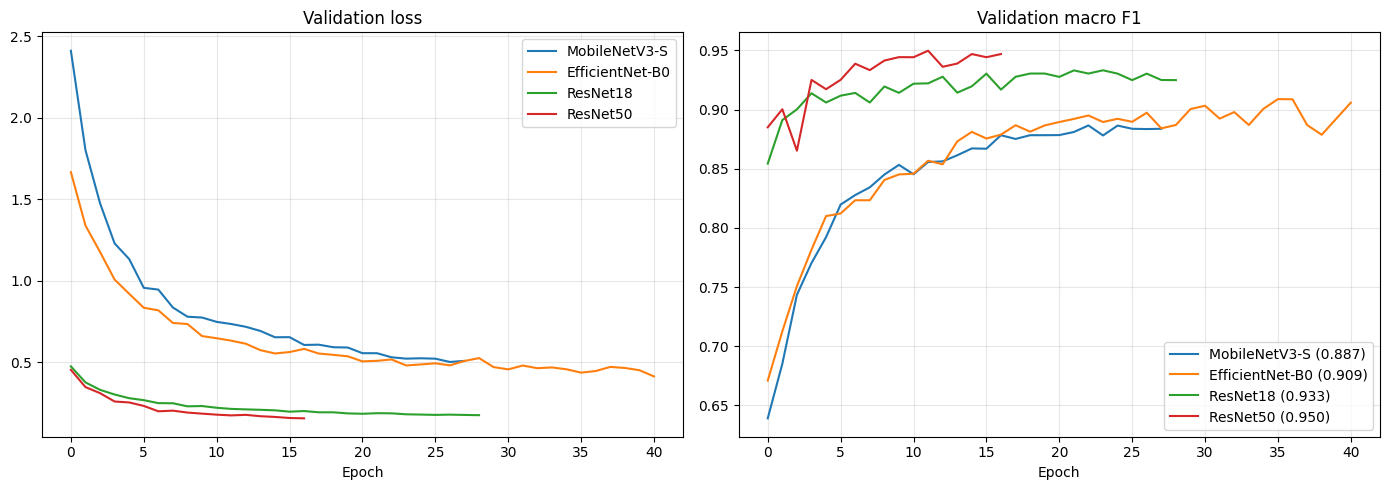

In [25]:
runs = [('MobileNetV3-S', hist_mob), ('EfficientNet-B0', hist_eff),
        ('ResNet18', hist_r18), ('ResNet50', hist_r50)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, h in runs:
    ax1.plot(h[2], label=name)                                  # val loss
    ax2.plot(h[4], label=f"{name} ({max(h[4]):.3f})")           # val F1

ax1.set_title('Validation loss'); ax1.set_xlabel('Epoch')
ax2.set_title('Validation macro F1'); ax2.set_xlabel('Epoch')
ax1.legend(); ax2.legend()
ax1.grid(alpha=.3); ax2.grid(alpha=.3)

plt.tight_layout(); plt.show()

## 4. Fine-tuning

Unfreeze `layer4` of the two best backbones, ResNet18 and ResNet50.

In [26]:
model_r18_ft, hist_r18_ft = finetune_resnet(model_r18, trainloader, valloader, criterion, f'{CKPT_DIR}/ResNet18_ft', device)

8,394,754 trainable
Epoch 1/40, Train Loss: 0.1539, Train Acc: 0.9467, Val Loss: 0.1641, Val Acc: 0.9396, Val F1: 0.9387
  lr: 1.0e-04
Epoch 2/40, Train Loss: 0.1266, Train Acc: 0.9608, Val Loss: 0.1514, Val Acc: 0.9368, Val F1: 0.9361
  lr: 1.0e-04
Epoch 3/40, Train Loss: 0.0963, Train Acc: 0.9741, Val Loss: 0.1438, Val Acc: 0.9423, Val F1: 0.9416
  lr: 1.0e-04
Epoch 4/40, Train Loss: 0.0851, Train Acc: 0.9812, Val Loss: 0.1398, Val Acc: 0.9505, Val F1: 0.9498
  lr: 1.0e-04
Epoch 5/40, Train Loss: 0.0682, Train Acc: 0.9843, Val Loss: 0.1411, Val Acc: 0.9368, Val F1: 0.9363
  lr: 1.0e-04
Epoch 6/40, Train Loss: 0.0590, Train Acc: 0.9867, Val Loss: 0.1283, Val Acc: 0.9451, Val F1: 0.9443
  lr: 1.0e-04
Epoch 7/40, Train Loss: 0.0470, Train Acc: 0.9922, Val Loss: 0.1289, Val Acc: 0.9423, Val F1: 0.9414
  lr: 1.0e-04
Epoch 8/40, Train Loss: 0.0401, Train Acc: 0.9945, Val Loss: 0.1215, Val Acc: 0.9478, Val F1: 0.9471
  lr: 1.0e-05
Epoch 9/40, Train Loss: 0.0374, Train Acc: 0.9961, Val Loss:

In [27]:
model_r50_ft, hist_r50_ft = finetune_resnet(model_r50, trainloader, valloader, criterion, f'{CKPT_DIR}/ResNet50_ft', device)

14,968,834 trainable
Epoch 1/40, Train Loss: 0.1619, Train Acc: 0.9545, Val Loss: 0.1468, Val Acc: 0.9423, Val F1: 0.9417
  lr: 1.0e-04
Epoch 2/40, Train Loss: 0.1162, Train Acc: 0.9694, Val Loss: 0.1348, Val Acc: 0.9423, Val F1: 0.9416
  lr: 1.0e-04
Epoch 3/40, Train Loss: 0.0892, Train Acc: 0.9749, Val Loss: 0.1275, Val Acc: 0.9451, Val F1: 0.9443
  lr: 1.0e-04
Epoch 4/40, Train Loss: 0.0725, Train Acc: 0.9796, Val Loss: 0.1261, Val Acc: 0.9368, Val F1: 0.9362
  lr: 1.0e-04
Epoch 5/40, Train Loss: 0.0560, Train Acc: 0.9937, Val Loss: 0.1186, Val Acc: 0.9423, Val F1: 0.9418
  lr: 1.0e-04
Epoch 6/40, Train Loss: 0.0558, Train Acc: 0.9906, Val Loss: 0.1144, Val Acc: 0.9423, Val F1: 0.9416
  lr: 1.0e-04
Epoch 7/40, Train Loss: 0.0381, Train Acc: 0.9937, Val Loss: 0.1152, Val Acc: 0.9505, Val F1: 0.9500
  lr: 1.0e-04
Epoch 8/40, Train Loss: 0.0268, Train Acc: 0.9969, Val Loss: 0.1171, Val Acc: 0.9505, Val F1: 0.9501
  lr: 1.0e-04
Epoch 9/40, Train Loss: 0.0275, Train Acc: 0.9945, Val Loss

### Fine-tuning results (`layer4` unfrozen, lr=1e-4 + ReduceLROnPlateau)

| Model | Screening F1 | Fine-tuned F1 | Δ |
|:---|---:|---:|---:|
| ResNet18 | 0.9333 | 0.9498 | +1.7 |
| ResNet50 | 0.9498 | **0.9557** | +0.6 |

- **Both now memorise the training set:** train accuracy 99.5% (ResNet18) and 100% (ResNet50)
- **ResNet50 overfits visibly:** validation loss rises after epoch 5 while F1 stays flat
- **Next:** augmentation as regulariser, starting again from the screening checkpoint

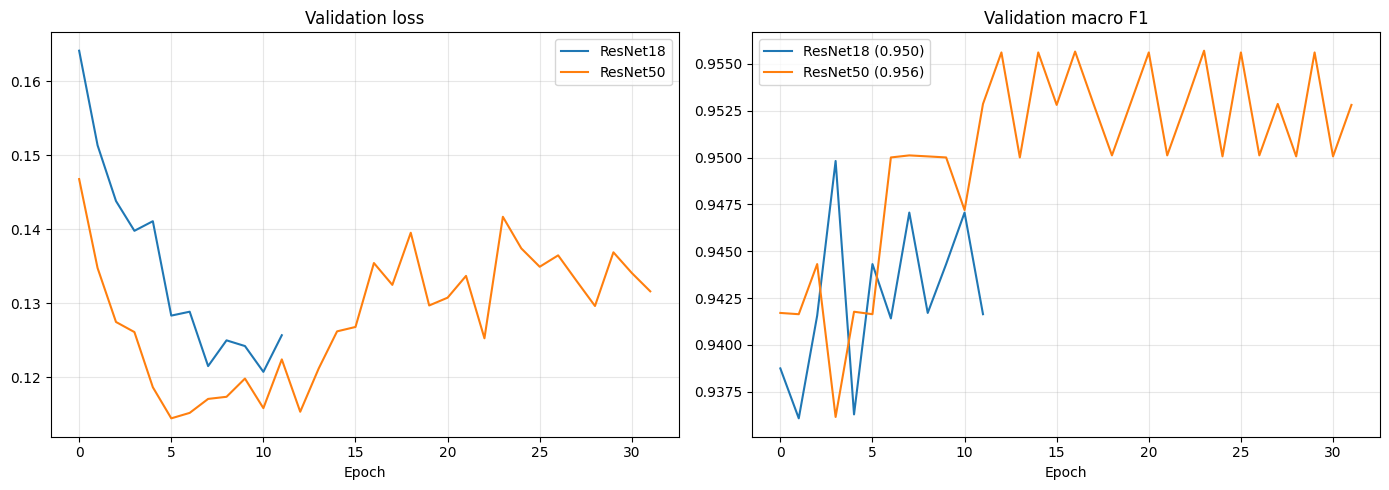

In [28]:
runs = [('ResNet18', hist_r18_ft), ('ResNet50', hist_r50_ft)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, h in runs:
    ax1.plot(h[2], label=name)                                  # val loss
    ax2.plot(h[4], label=f"{name} ({max(h[4]):.3f})")           # val F1

ax1.set_title('Validation loss'); ax1.set_xlabel('Epoch')
ax2.set_title('Validation macro F1'); ax2.set_xlabel('Epoch')
ax1.legend(); ax2.legend()
ax1.grid(alpha=.3); ax2.grid(alpha=.3)

plt.tight_layout(); plt.show()

## 5. Data Augmentation

| Transform | Kept | Why |
|:---|:---|:---|
| `RandomResizedCrop(scale=(0.6, 1.0))` | yes | Field images vary in distance and framing; 512→224 leaves room for crops |
| `HorizontalFlip` + `VerticalFlip` | yes | Flowers are radially symmetric — unlike food, an upside-down daisy is still a plausible image |
| `Rotate(limit=45)` | yes | Drone and field sensors shoot from arbitrary angles |
| `RandomBrightnessContrast(0.2)` | yes | Simulates changing natural light, without shifting hue |
| Hue / saturation shift | **no** | **Colour is the primary signal here** — white petals vs yellow head. Perturbing hue would destroy the very feature that separates the two classes |

**Border handling:** rotations left black corners in the output.
Switched to BORDER_REFLECT_101, which fills the corners by mirroring.

In [29]:
transform_aug = A.Compose([
    A.RandomResizedCrop(size=(224, 224), scale=(0.6, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=45, border_mode=cv2.BORDER_REFLECT_101, p=0.7),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

trainset_aug = torchvision.datasets.ImageFolder(f'{ROOT}/train', transform=Transforms(transform_aug))
trainloader_aug = DataLoader(trainset_aug, batch_size=BATCH_SIZE, shuffle=True,
                             num_workers=2, pin_memory=True)

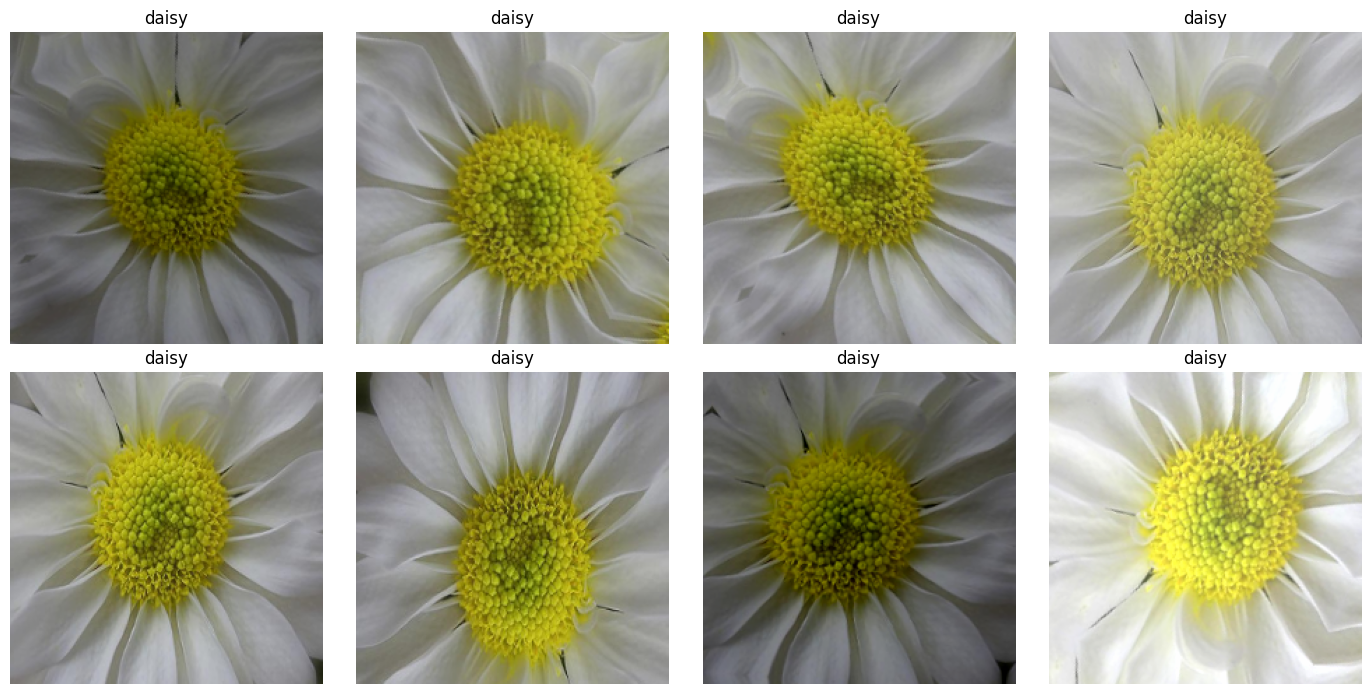

In [30]:
MEAN = np.array([0.485, 0.456, 0.406])
STD  = np.array([0.229, 0.224, 0.225])

def back_to_image(img):
    npimg = img.numpy().transpose(1, 2, 0)
    return np.clip(npimg * STD + MEAN, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax in axes.ravel():
    img, label = trainset_aug[0]
    ax.imshow(back_to_image(img))
    ax.set_title(trainset_aug.classes[label]); ax.axis('off')
plt.tight_layout(); plt.show()

In [31]:
# Same starting point and budget as the fine-tuning branch: only the training transforms differ
model_r18_aug, hist_r18_aug = finetune_resnet(model_r18, trainloader_aug, valloader, criterion, f'{CKPT_DIR}/ResNet18_aug', device)

8,394,754 trainable
Epoch 1/40, Train Loss: 0.1977, Train Acc: 0.9271, Val Loss: 0.1659, Val Acc: 0.9423, Val F1: 0.9417
  lr: 1.0e-04
Epoch 2/40, Train Loss: 0.1886, Train Acc: 0.9231, Val Loss: 0.1610, Val Acc: 0.9341, Val F1: 0.9335
  lr: 1.0e-04
Epoch 3/40, Train Loss: 0.1633, Train Acc: 0.9396, Val Loss: 0.1482, Val Acc: 0.9451, Val F1: 0.9444
  lr: 1.0e-04
Epoch 4/40, Train Loss: 0.1573, Train Acc: 0.9427, Val Loss: 0.1458, Val Acc: 0.9423, Val F1: 0.9416
  lr: 1.0e-04
Epoch 5/40, Train Loss: 0.1474, Train Acc: 0.9380, Val Loss: 0.1414, Val Acc: 0.9478, Val F1: 0.9474
  lr: 1.0e-04
Epoch 6/40, Train Loss: 0.1390, Train Acc: 0.9467, Val Loss: 0.1340, Val Acc: 0.9396, Val F1: 0.9390
  lr: 1.0e-04
Epoch 7/40, Train Loss: 0.1306, Train Acc: 0.9529, Val Loss: 0.1324, Val Acc: 0.9478, Val F1: 0.9474
  lr: 1.0e-04
Epoch 8/40, Train Loss: 0.1251, Train Acc: 0.9576, Val Loss: 0.1276, Val Acc: 0.9505, Val F1: 0.9500
  lr: 1.0e-04
Epoch 9/40, Train Loss: 0.1146, Train Acc: 0.9576, Val Loss:

In [32]:
model_r50_aug, hist_r50_aug = finetune_resnet(model_r50, trainloader_aug, valloader, criterion, f'{CKPT_DIR}/ResNet50_aug', device)

14,968,834 trainable
Epoch 1/40, Train Loss: 0.2008, Train Acc: 0.9231, Val Loss: 0.1608, Val Acc: 0.9396, Val F1: 0.9387
  lr: 1.0e-04
Epoch 2/40, Train Loss: 0.1795, Train Acc: 0.9239, Val Loss: 0.1509, Val Acc: 0.9396, Val F1: 0.9389
  lr: 1.0e-04
Epoch 3/40, Train Loss: 0.1620, Train Acc: 0.9341, Val Loss: 0.1349, Val Acc: 0.9451, Val F1: 0.9443
  lr: 1.0e-04
Epoch 4/40, Train Loss: 0.1291, Train Acc: 0.9529, Val Loss: 0.1321, Val Acc: 0.9478, Val F1: 0.9473
  lr: 1.0e-04
Epoch 5/40, Train Loss: 0.1368, Train Acc: 0.9475, Val Loss: 0.1321, Val Acc: 0.9396, Val F1: 0.9390
  lr: 1.0e-04
Epoch 6/40, Train Loss: 0.1255, Train Acc: 0.9490, Val Loss: 0.1146, Val Acc: 0.9505, Val F1: 0.9499
  lr: 1.0e-04
Epoch 7/40, Train Loss: 0.1140, Train Acc: 0.9600, Val Loss: 0.1151, Val Acc: 0.9533, Val F1: 0.9528
  lr: 1.0e-04
Epoch 8/40, Train Loss: 0.1017, Train Acc: 0.9584, Val Loss: 0.1130, Val Acc: 0.9478, Val F1: 0.9472
  lr: 1.0e-04
Epoch 9/40, Train Loss: 0.0969, Train Acc: 0.9663, Val Loss

### Augmentation results (clean ablation)

| Model | Fine-tuning | Fine-tuning + augmentation | Δ |
|:---|---:|---:|---:|
| ResNet18 | 0.9498 | **0.9611** | +1.1 |
| ResNet50 | **0.9557** | 0.9528 | −0.3 |

- Both branches start from the same screening checkpoint with the same epoch budget: the Δ is augmentation only
- **ResNet18:** +1.1 points (~4 validation images); train accuracy stays below 97%, so augmentation is regularising
- **ResNet50:** no gain (−1 image)
- **Caution:** 0.9611 is a single-epoch peak; neighbouring epochs sit around 0.955

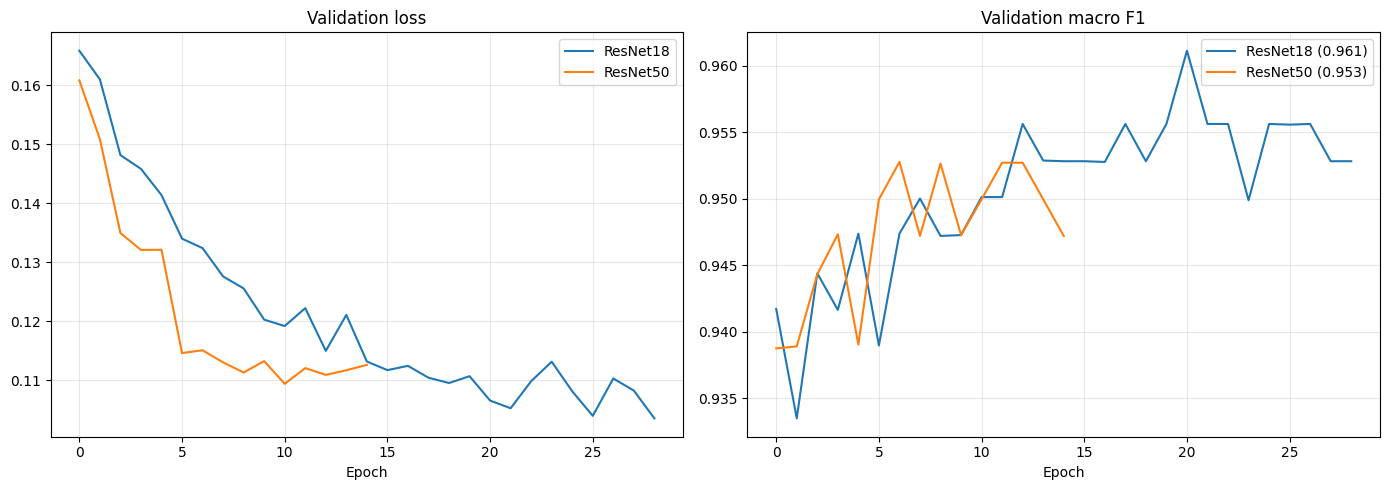

In [33]:
runs = [('ResNet18', hist_r18_aug), ('ResNet50', hist_r50_aug)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for name, h in runs:
    ax1.plot(h[2], label=name)                                  # val loss
    ax2.plot(h[4], label=f"{name} ({max(h[4]):.3f})")           # val F1

ax1.set_title('Validation loss'); ax1.set_xlabel('Epoch')
ax2.set_title('Validation macro F1'); ax2.set_xlabel('Epoch')
ax1.legend(); ax2.legend()
ax1.grid(alpha=.3); ax2.grid(alpha=.3)

plt.tight_layout(); plt.show()

## 6. Test On Best Model

- Final model picked automatically on validation F1 (ties go to the smaller network)
- Evaluated **once** on the test set (182 images)

In [34]:
# Final model chosen on validation F1 only; on a tie, max() keeps the first listed (the smaller network)
candidates = {
    'ResNet18_ft':  (model_r18_ft,  hist_r18_ft),
    'ResNet18_aug': (model_r18_aug, hist_r18_aug),
    'ResNet50_ft':  (model_r50_ft,  hist_r50_ft),
    'ResNet50_aug': (model_r50_aug, hist_r50_aug),
}
for name, (_, h) in candidates.items():
    print(f"{name:14s} best val F1 {max(h[4]):.4f}")

best_name  = max(candidates, key=lambda n: max(candidates[n][1][4]))
best_model = candidates[best_name][0]      # best weights already restored by early stopping
print(f"\nselected: {best_name}")

ResNet18_ft    best val F1 0.9498
ResNet18_aug   best val F1 0.9611
ResNet50_ft    best val F1 0.9557
ResNet50_aug   best val F1 0.9528

selected: ResNet18_aug


In [35]:
test_loss, test_acc, test_f1 = evaluate(best_model, testloader, criterion, device)
print(f"TEST — loss {test_loss:.4f} | accuracy {test_acc:.4f} | macro F1 {test_f1:.4f}")

TEST — loss 0.1132 | accuracy 0.9396 | macro F1 0.9378


## 7. Final evaluation

| | Validation (364) | Test (182) |
|:---|---:|---:|
| **Macro F1** | 0.9611 | **0.9378** |

- **Gap of 2.3 points ≈ 4 test images** (one image ≈ 0.55 points), consistent with the validation peak above
- **Daisy recall 0.909** (7 of 77 missed), dandelion recall 0.962 (4 of 105 missed)

In [36]:
y_true, y_pred = evaluate_report(best_model, testloader, testset.classes, device)

              precision    recall  f1-score   support

       daisy     0.9459    0.9091    0.9272        77
   dandelion     0.9352    0.9619    0.9484       105

    accuracy                         0.9396       182
   macro avg     0.9406    0.9355    0.9378       182
weighted avg     0.9397    0.9396    0.9394       182



### Error analysis

misclassified: 11 / 182


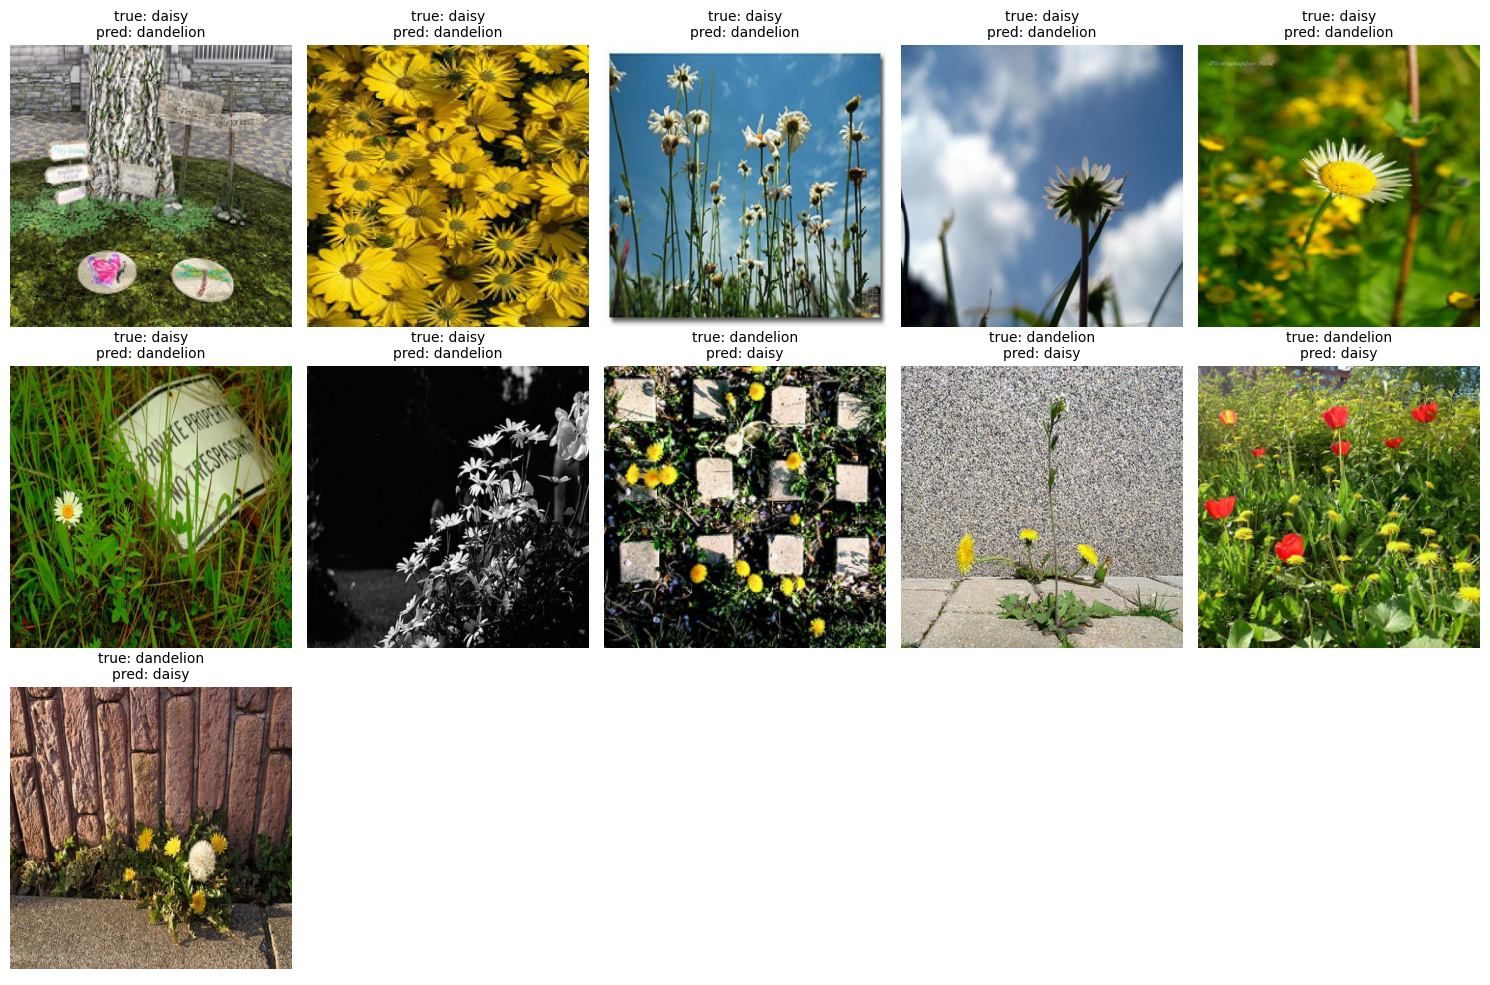

In [37]:
# Test images the final model gets wrong; testloader is not shuffled, so indices match testset
wrong = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t != p]
print(f"misclassified: {len(wrong)} / {len(y_true)}")

cols = 5
rows = int(np.ceil(len(wrong) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3.3 * rows))
for ax in axes.ravel():
    ax.axis('off')
for ax, i in zip(axes.ravel(), wrong):
    path, label = testset.samples[i]
    ax.imshow(Image.open(path))                 # original 512×512 photo, easier to read than the 224 tensor
    ax.set_title(f"true: {testset.classes[label]}\npred: {testset.classes[y_pred[i]]}", fontsize=10)
plt.tight_layout(); plt.show()

**11 errors, four patterns:**
- **Colour missing or misleading:** a black-and-white photo, and two "daisies" that are yellow species — the model follows colour, which is the right cue for these two classes
- **Small flowers in clutter:** flowers occupying a small part of the frame, among pavers, gravel, signs or other species
- **Unusual viewpoint:** daisies shot from below against the sky
- **Dandelion seed heads:** a white puffball reads as a daisy

**What to collect next:** top-down and close-range field shots, small flowers in cluttered scenes, dandelion seed heads. The yellow "daisy" images should be reviewed: they may be label noise.

## 8. Robustness to field conditions

The test images are clean 512×512 photos; drone and field sensors are not.
Each perturbation is applied to the full-size test image before resizing, at a fixed severity,
and the final model is re-evaluated. Brightness shifts go beyond the ±0.2 used in training.

In [38]:
# One fixed-severity perturbation per field condition (p=1: always applied)
perturbations = {
    'clean':        None,
    'motion blur':  A.MotionBlur(blur_limit=(15, 15), p=1),
    'low light':    A.RandomBrightnessContrast(brightness_limit=(-0.4, -0.4), contrast_limit=(0, 0), p=1),
    'harsh light':  A.RandomBrightnessContrast(brightness_limit=(0.4, 0.4), contrast_limit=(0.3, 0.3), p=1),
    'sensor noise': A.GaussNoise(std_range=(0.1, 0.1), p=1),
    'fog':          A.RandomFog(fog_coef_range=(0.5, 0.5), p=1),
    'occlusion':    A.CoarseDropout(num_holes_range=(4, 4), hole_height_range=(0.2, 0.2),
                                    hole_width_range=(0.2, 0.2), p=1),
}

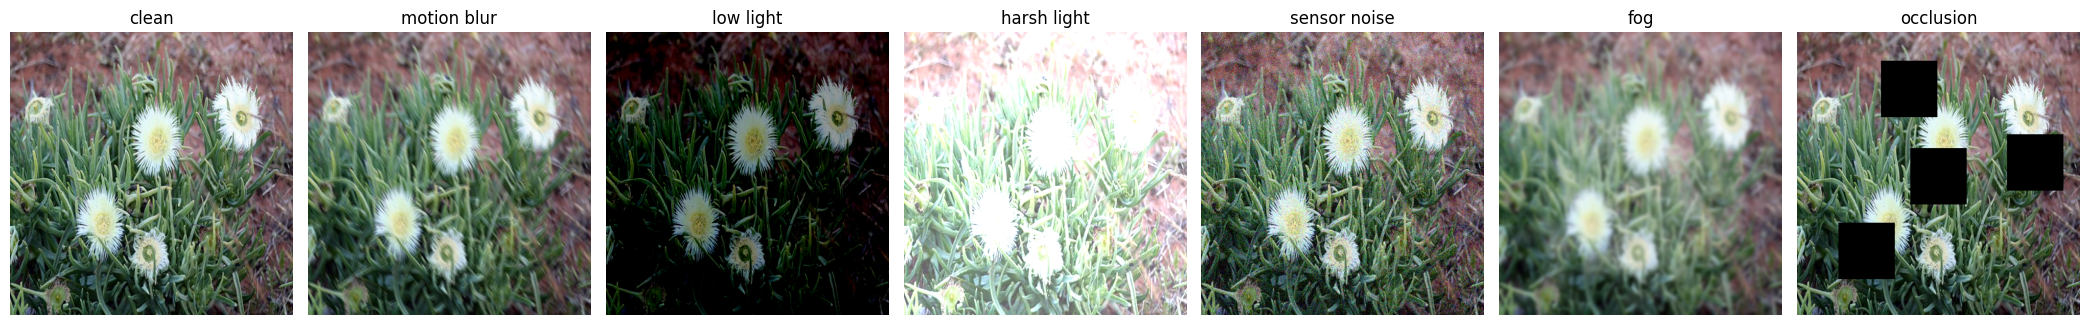

In [39]:
# Same test image under every condition
path, _ = testset.samples[0]
img = np.array(Image.open(path))

fig, axes = plt.subplots(1, len(perturbations), figsize=(3 * len(perturbations), 3.3))
for ax, (name, pert) in zip(axes, perturbations.items()):
    shown = img if pert is None else A.Compose([pert], seed=SEED)(image=img)['image']
    ax.imshow(shown); ax.set_title(name); ax.axis('off')
plt.tight_layout(); plt.show()

In [40]:
def eval_perturbed(model, perturbation, criterion, device):
    """Test macro F1 with one perturbation applied to the full-size image before resizing."""
    steps = [] if perturbation is None else [perturbation]
    tf = A.Compose(steps + [A.Resize(224, 224),
                            A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
                            ToTensorV2()], seed=SEED)    # seeded: same noise / holes on every run
    ds = torchvision.datasets.ImageFolder(f'{ROOT}/test', transform=Transforms(tf))
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)  # 0 workers keeps the seed effective
    _, _, f1 = evaluate(model, loader, criterion, device)
    return f1

In [41]:
clean_f1 = eval_perturbed(best_model, None, criterion, device)
print(f"{'condition':14s} {'macro F1':>9s} {'drop':>8s}")
print("-" * 33)
for name, pert in perturbations.items():
    f1 = clean_f1 if pert is None else eval_perturbed(best_model, pert, criterion, device)
    print(f"{name:14s} {f1:9.4f} {f1 - clean_f1:+8.4f}")

condition       macro F1     drop
---------------------------------
clean             0.9378  +0.0000
motion blur       0.9550  +0.0172
low light         0.9384  +0.0006
harsh light       0.9096  -0.0281
sensor noise      0.9382  +0.0004
fog               0.9038  -0.0340
occlusion         0.8939  -0.0438


| Condition | Macro F1 | Δ vs clean |
|:---|---:|---:|
| clean | 0.9378 | — |
| motion blur | 0.9550 | +1.7 |
| low light | 0.9384 | +0.1 |
| sensor noise | 0.9382 | +0.0 |
| harsh light | 0.9096 | −2.8 |
| fog | 0.9038 | −3.4 |
| occlusion | 0.8939 | −4.4 |

- **Robust to:** motion blur, low light and sensor noise — no degradation
- **Sensitive to:** harsh light and fog (~5–6 extra errors), which wash out the white/yellow contrast the model relies on
- **Most sensitive to:** occlusion (~8 extra errors), which hides the flower head
- Consistent with the error analysis: the model is a colour-and-flower-head detector

## 9. Conclusions

**Final model: ResNet18, `layer4` fine-tuned with augmentation — test macro F1 0.9378 (11 errors / 182).**

**Advantages**
- High accuracy with 11M parameters, half of ResNet50 at equal or better validation F1
- Unaffected by motion blur, low light and sensor noise, the most common drone artefacts

**Challenges for field deployment**
- Harsh sunlight, fog and partial occlusion cost 3–4 points
- Small flowers in clutter, unusual viewpoints and dandelion seed heads cause most errors
- Two classes only: the result says nothing about the dozens of species in a real crop

**Recommendation for GreenTech**
- Fit for a pilot in clear daylight; flag low-confidence predictions in harsh light or fog for human review
- Collect top-down drone images, cluttered scenes and seed heads; review the yellow "daisy" images

**Limits of this study**
- Single training run per configuration; 182 test images, so one image ≈ 0.55 points
- Perturbations are synthetic: real drone footage is the only definitive test